# Random Forest — Heart Disease Prediction

**Module:** IT5052 – Fundamentals of Machine Learning
**Program:** MSc in Artificial Intelligence, SLIIT (2026/JAN)
**Algorithm:** Random Forest Classifier
**Task:** Binary classification — predict whether a patient has heart disease

This notebook continues from the preprocessing pipeline.
Pre-split, pre-scaled data is loaded from `output/csv/`.

## 1. Algorithm Background — Random Forest

Random Forest is a supervised learning algorithm that is an ensemble of supervised learning algorithms. It constructs several decision trees based on random samples of the data and random subsets of features, and fuses the predictions of these trees by majority voting (in classification). Such randomness minimizes overfitting and enhances accuracy. Random Forest is a high variance, low variance, and high performance random forest that average numerous trees to perform well on unseen data.

###  1.2. Why Random Forest for Heart Disease Prediction

Random Forest is especially suitable in predicting heart diseases due to the characteristics of the data set and the problem specifications. In the medical case, medical data is usually made of both numeric and categorical (coded) variables, including age, cholesterol, blood pressure, and types of chest pain. These types of features can be naturally handled by decision trees without complex preprocessing and scaling.

The other significant benefit is that the model has the capability to model non-linear relationships and interactions among features. Risk factors in healthcare data are not independent- e.g., risk of disease could be greatly affected by age, cholesterol, and blood pressure. Random Forest models these interactions automatically without having to manually engineer the features.

Also important in medical applications is interpretability. Random Forest also gives out feature importance scores, which are useful in determining the factors that make the most contributions to the predictions. This can be helpful to clinicians who must be aware and have confidence in the decisions of the model.

Also, datasets on heart diseases are frequently affected by the imbalance in classes; the number of healthy cases dominates the number of disease cases. These can be effectively done using random forest techniques like class weighting or resampling. It is also resistant to outliers, as tree-based models do not use the absolute values but per order of data, so extreme lab measurements do not have a potent impact on predictions.

Finally, Random Forest is more predictable, simpler to train, tune, and deploy, unlike deep learning techniques, which need large volumes of data to perform well.

## 2. Setup & Imports

In [1]:
# Standard libs
import os
import json
import logging
from pathlib import Path

import pandas as pd
import numpy as np

# Visualisation 
import matplotlib.pyplot as plt
import seaborn as sns

# ML libs
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
)
from sklearn.inspection import permutation_importance

# SMOTE (optional)
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_SMOTE = True
except ImportError:
    print("imbalanced-learn not installed — SMOTE section will be skipped.")
    print("Install with: pip install imbalanced-learn")
    HAS_SMOTE = False

# Save model
import joblib

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot defaults 
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 3. Define Paths

In [2]:
BASE_DIR = Path(os.getcwd()).parent

DATA_DIR = BASE_DIR / "output" / "csv"
MODEL_DIR = BASE_DIR / "output" / "model"
METRIC_DIR = BASE_DIR / "output" / "metrics"
PLOT_DIR    = BASE_DIR / "output" / "plots"
LOG_DIR     = BASE_DIR / "output" / "logs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("PLOT_DIR :", PLOT_DIR)

DATA_DIR: d:\Master of Science Artificial Intelligence\Semester - 01\IT5022 - Fundamentals of Machine Learning\Group assignment\Machine-Learning-Programming-Assignment-IT5052\output\csv
MODEL_DIR: d:\Master of Science Artificial Intelligence\Semester - 01\IT5022 - Fundamentals of Machine Learning\Group assignment\Machine-Learning-Programming-Assignment-IT5052\output\model
PLOT_DIR : d:\Master of Science Artificial Intelligence\Semester - 01\IT5022 - Fundamentals of Machine Learning\Group assignment\Machine-Learning-Programming-Assignment-IT5052\output\plots


## 4. Logging

In [3]:
# Append to the same log file the preprocessing notebook writes to,
log_file = LOG_DIR / "app.log"

for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    filename=log_file,
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - [RandomForest] - %(message)s",
)
logger = logging.getLogger(__name__)
logger.info("Random Forest notebook started.")


## 5. Load Pre-processed Data

In [4]:
# Load preprocessed data
X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_test = pd.read_csv(DATA_DIR / "X_test.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze()
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze()

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)
logger.info(f"Loaded train={X_train.shape}, test={X_test.shape}")

Train Shape: (8000, 20)
Test Shape: (2000, 20)


## 6. Basic Data Validation

In [5]:
assert not X_train.isnull().any().any(), "Missing values in X_train"
assert not X_test.isnull().any().any(), "Missing values in X_test"

assert len(X_train) == len(y_train), "Mismatch in training data"
assert len(X_test) == len(y_test), "Mismatch in test data"

assert set(y_train.unique()) <= {0, 1}, "Target should be binary 0/1"

print("Data validation passed")
logger.info("Data validation passed.")

Data validation passed


## 7. Class Distribution Check

Class counts (train):
                      count  percent
Heart Disease Status                
0                      6400     80.0
1                      1600     20.0


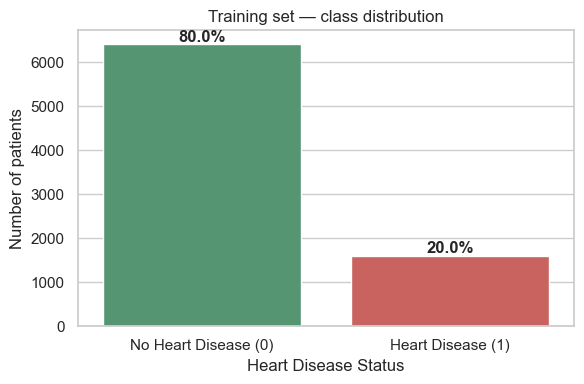


Imbalance ratio (majority : minority) = 4.00 : 1


In [6]:
# Show the class balance numerically and visually.
class_counts = y_train.value_counts().sort_index()
class_pct = (class_counts / len(y_train) * 100).round(2)

print("Class counts (train):")
print(pd.DataFrame({"count": class_counts, "percent": class_pct}))

# Visualise
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values,
            hue=class_counts.index, palette=["#4C9F70", "#D9534F"], legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Heart Disease (0)", "Heart Disease (1)"])
ax.set_ylabel("Number of patients")
ax.set_title("Training set — class distribution")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + max(class_counts.values) * 0.01, f"{class_pct.iloc[i]}%",
            ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

# Compute imbalance ratio
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (majority : minority) = {imbalance_ratio:.2f} : 1")
logger.info(f"Class imbalance ratio: {imbalance_ratio:.2f}:1")


## 8. Default Random Forest (Baseline)

In [7]:
# default RF with 100 trees, no class_weight (since imbalance ratio < 3:1)
baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
baseline_pred = baseline_model.predict(X_test)
baseline_prob = baseline_model.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "accuracy" : accuracy_score(y_test, baseline_pred),
    "precision": precision_score(y_test, baseline_pred, zero_division=0),
    "recall"   : recall_score(y_test, baseline_pred, zero_division=0),
    "f1"       : f1_score(y_test, baseline_pred, zero_division=0),
    "roc_auc"  : roc_auc_score(y_test, baseline_prob),
}
print("Baseline metrics:")
for k, v in baseline_metrics.items():
    print(f"  {k:9s}: {v:.4f}")

logger.info(f"Baseline metrics: {baseline_metrics}")

Baseline metrics:
  accuracy : 0.8000
  precision: 0.0000
  recall   : 0.0000
  f1       : 0.0000
  roc_auc  : 0.5090


## 9. Hyperparameter Tuning (GridSearchCV)

In [9]:
param_grid = {
    "n_estimators"     : [200, 400],          # more trees = more stable, slower
    "max_depth"        : [None, 10, 20],      # None = grow until pure
    "min_samples_split": [2, 5],              # higher = more regularisation
    "min_samples_leaf" : [1, 2],              # higher = smoother trees
    "max_features"     : ["sqrt", "log2"],    # how many features per split
    "class_weight"     : [None, "balanced"],  # handle class imbalance
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",     # robust to class imbalance
    refit=True,            # refit best model on full training set
    verbose=1,
    n_jobs=-1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best CV ROC-AUC:", round(grid_search.best_score_, 4))
print("Best params    :", grid_search.best_params_)
logger.info(f"Best params: {grid_search.best_params_}")
logger.info(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best CV ROC-AUC: 0.5222
Best params    : {'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


## 10. Cross-Validation Stability of the Best Model

Per-fold ROC-AUC : [0.5425 0.5322 0.4975 0.5394 0.4997]
Mean ROC-AUC     : 0.5222
Std  ROC-AUC     : 0.0196


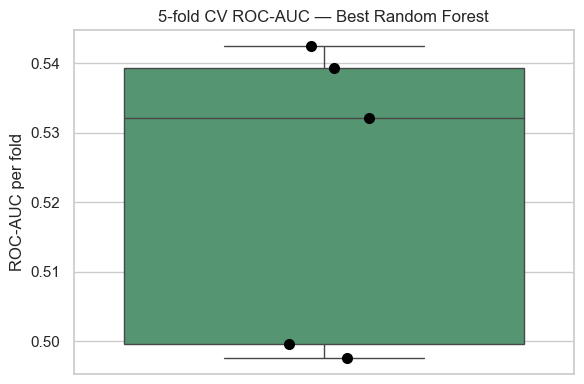

In [10]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv,
                             scoring="roc_auc", n_jobs=-1)

print("Per-fold ROC-AUC :", np.round(cv_scores, 4))
print(f"Mean ROC-AUC     : {cv_scores.mean():.4f}")
print(f"Std  ROC-AUC     : {cv_scores.std():.4f}")

# Visual: boxplot of fold scores
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(y=cv_scores, color="#4C9F70", ax=ax)
sns.stripplot(y=cv_scores, color="black", size=8, ax=ax)
ax.set_ylabel("ROC-AUC per fold")
ax.set_title("5-fold CV ROC-AUC — Best Random Forest")
plt.tight_layout()
plt.savefig(PLOT_DIR / "cv_scores_boxplot.png", dpi=120, bbox_inches="tight")
plt.show()


## 11. Final Evaluation on the Held-Out Test Set

In [11]:
# Predictions on the test set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Headline metrics
final_metrics = {
    "accuracy" : accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall"   : recall_score(y_test, y_pred, zero_division=0),
    "f1"       : f1_score(y_test, y_pred, zero_division=0),
    "roc_auc"  : roc_auc_score(y_test, y_prob),
}

print("Tuned Random Forest — test metrics")
print("-" * 40)
for k, v in final_metrics.items():
    print(f"  {k:9s}: {v:.4f}")

print("\nClassification Report")
print("-" * 40)
print(classification_report(y_test, y_pred,
                             target_names=["No Heart Disease", "Heart Disease"], zero_division=0))

logger.info(f"Final test metrics: {final_metrics}")

Tuned Random Forest — test metrics
----------------------------------------
  accuracy : 0.8000
  precision: 0.0000
  recall   : 0.0000
  f1       : 0.0000
  roc_auc  : 0.4905

Classification Report
----------------------------------------
                  precision    recall  f1-score   support

No Heart Disease       0.80      1.00      0.89      1600
   Heart Disease       0.00      0.00      0.00       400

        accuracy                           0.80      2000
       macro avg       0.40      0.50      0.44      2000
    weighted avg       0.64      0.80      0.71      2000



## 12. Baseline vs Tuned

           Baseline RF  Tuned RF   Delta
accuracy         0.800    0.8000  0.0000
precision        0.000    0.0000  0.0000
recall           0.000    0.0000  0.0000
f1               0.000    0.0000  0.0000
roc_auc          0.509    0.4905 -0.0185


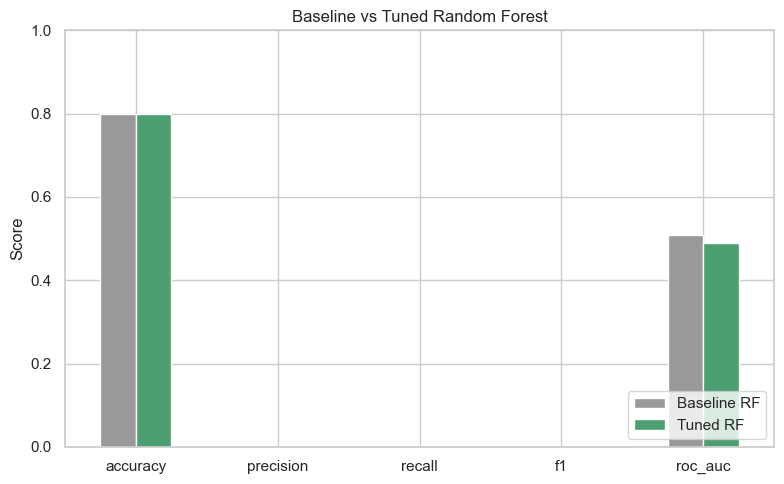

In [12]:
# Side-by-side comparison so the report can quantify the gain from tuning.
comparison_df = pd.DataFrame({
    "Baseline RF": baseline_metrics,
    "Tuned RF"   : final_metrics,
}).round(4)
comparison_df["Delta"] = (comparison_df["Tuned RF"] - comparison_df["Baseline RF"]).round(4)
print(comparison_df)

fig, ax = plt.subplots(figsize=(8, 5))
comparison_df[["Baseline RF", "Tuned RF"]].plot(kind="bar", ax=ax,
                                                 color=["#999999", "#4C9F70"])
ax.set_ylabel("Score")
ax.set_title("Baseline vs Tuned Random Forest")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOT_DIR / "baseline_vs_tuned.png", dpi=120, bbox_inches="tight")
plt.show()

## 13. Confusion Matrix

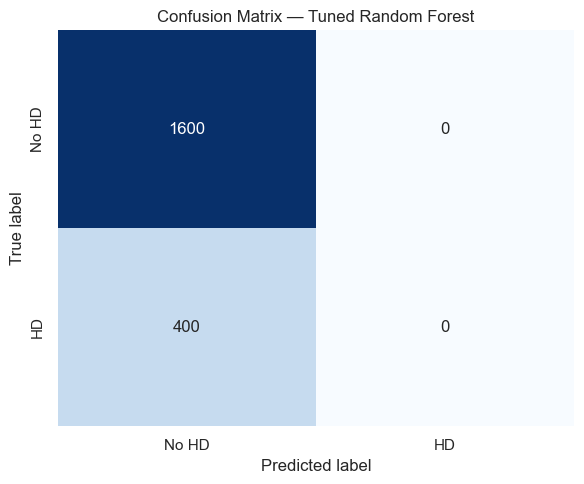

True Negatives : 1600
False Positives: 0  (healthy patients incorrectly flagged)
False Negatives: 400  (sick patients missed by model)
True Positives : 0


In [13]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No HD", "HD"],
            yticklabels=["No HD", "HD"], cbar=False, ax=ax)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix — Tuned Random Forest")
plt.tight_layout()
plt.savefig(PLOT_DIR / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}  (healthy patients incorrectly flagged)")
print(f"False Negatives: {fn}  (sick patients missed by model)")
print(f"True Positives : {tp}")

## 14. ROC and Precision-Recall Curves

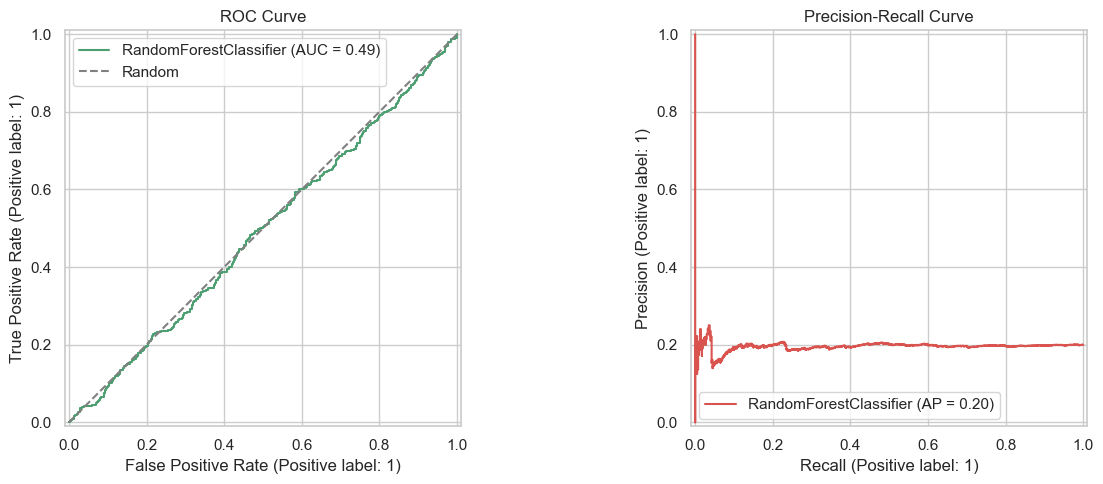

In [14]:
# ROC curve — true positive rate vs false positive rate at every threshold.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_estimator(best_model, X_test, y_test,
                                ax=axes[0], curve_kwargs={"color": "#4C9F70"})
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="Random")
axes[0].set_title("ROC Curve")
axes[0].legend()

# Precision-Recall is more informative than ROC when classes are imbalanced.
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test,
                                       ax=axes[1], color="#D9534F")
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.savefig(PLOT_DIR / "roc_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()


## 15. Feature Importance

feature importance two ways:

1. **Built-in (Gini) importance** — fast but biased toward
   high-cardinality features.
2. **Permutation importance** — model-agnostic and considered more
   trustworthy. Measures how much accuracy drops when a feature is
   randomly shuffled.

Top 10 features (Gini importance):
            feature  importance
                BMI    0.101247
 Homocysteine Level    0.096261
          CRP Level    0.096093
        Sleep Hours    0.094624
 Triglyceride Level    0.091769
  Cholesterol Level    0.089508
Fasting Blood Sugar    0.084560
                Age    0.082599
     Blood Pressure    0.082545
  Sugar Consumption    0.022753


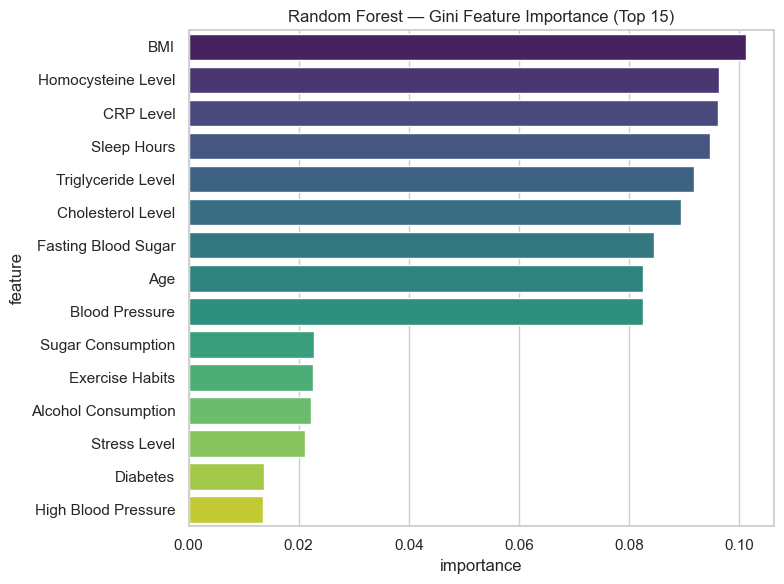

In [15]:
# Built-in Gini importance
feat_imp = pd.DataFrame({
    "feature"   : X_train.columns,
    "importance": best_model.feature_importances_,
}).sort_values("importance", ascending=False)

print("Top 10 features (Gini importance):")
print(feat_imp.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=feat_imp.head(15), y="feature", x="importance",
            hue="feature", palette="viridis", legend=False, ax=ax)
ax.set_title("Random Forest — Gini Feature Importance (Top 15)")
plt.tight_layout()
plt.savefig(PLOT_DIR / "feature_importance_gini.png", dpi=120, bbox_inches="tight")
plt.show()

feat_imp.to_csv(METRIC_DIR / "feature_importance.csv", index=False)


Top 10 features (Permutation importance):
             feature  perm_importance_mean  perm_importance_std
                 Age              0.011790             0.008336
              Gender              0.007851             0.002079
Family Heart Disease              0.007184             0.002045
 Fasting Blood Sugar              0.007016             0.006051
     Exercise Habits              0.004618             0.003810
   Sugar Consumption              0.004435             0.004605
  Homocysteine Level              0.003891             0.007502
 High Blood Pressure              0.001897             0.002944
 Low HDL Cholesterol              0.000679             0.003339
         Sleep Hours              0.000425             0.006679


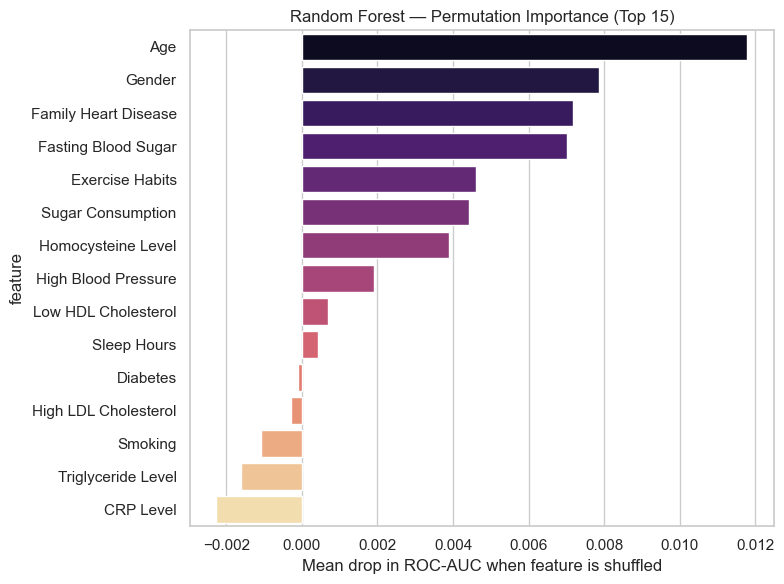

In [16]:
# Permutation importance (more reliable)
perm = permutation_importance(best_model, X_test, y_test,
                                n_repeats=10,
                                random_state=RANDOM_STATE,
                                n_jobs=-1,
                                scoring="roc_auc")

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "perm_importance_mean": perm.importances_mean,
    "perm_importance_std" : perm.importances_std,
}).sort_values("perm_importance_mean", ascending=False)

print("Top 10 features (Permutation importance):")
print(perm_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=perm_df.head(15), y="feature", x="perm_importance_mean",
            hue="feature", palette="magma", legend=False, ax=ax)
ax.set_title("Random Forest — Permutation Importance (Top 15)")
ax.set_xlabel("Mean drop in ROC-AUC when feature is shuffled")
plt.tight_layout()
plt.savefig(PLOT_DIR / "feature_importance_permutation.png", dpi=120, bbox_inches="tight")
plt.show()

perm_df.to_csv(METRIC_DIR / "feature_importance_permutation.csv", index=False)


## 16. Learning Curve 

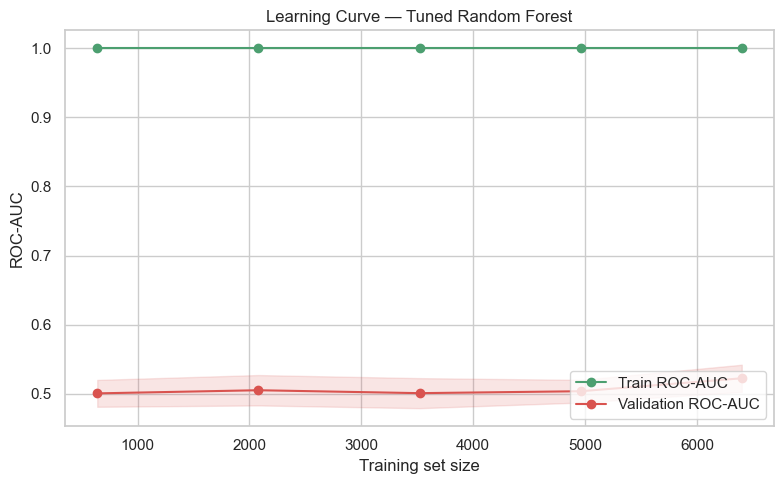

In [17]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    cv=cv,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean,   val_std   = val_scores.mean(axis=1),   val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, "o-", color="#4C9F70", label="Train ROC-AUC")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color="#4C9F70")
ax.plot(train_sizes, val_mean, "o-", color="#D9534F", label="Validation ROC-AUC")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color="#D9534F")
ax.set_xlabel("Training set size")
ax.set_ylabel("ROC-AUC")
ax.set_title("Learning Curve — Tuned Random Forest")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(PLOT_DIR / "learning_curve.png", dpi=120, bbox_inches="tight")
plt.show()


## 17. Persist Model, Metrics & Predictions

In [18]:
# Save metrics
all_metrics = {
    "baseline": baseline_metrics,
    "tuned"   : final_metrics,
    "best_params": grid_search.best_params_,
    "cv_mean_roc_auc": float(cv_scores.mean()),
    "cv_std_roc_auc" : float(cv_scores.std()),
}
with open(METRIC_DIR / "rf_metrics.json", "w") as f:
    json.dump(all_metrics, f, indent=4)

pd.DataFrame([final_metrics]).to_csv(METRIC_DIR / "metrics.csv", index=False)

# Save predictions for the report's appendix / error analysis
pred_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred,
    "y_prob": y_prob,
})
pred_df.to_csv(METRIC_DIR / "predictions.csv", index=False)

# Save model 
joblib.dump(best_model, MODEL_DIR / "random_forest_model.pkl")

print("Saved:")
print(f"  metrics.json -> {METRIC_DIR / 'rf_metrics.json'}")
print(f"  metrics.csv  -> {METRIC_DIR / 'metrics.csv'}")
print(f"  predictions  -> {METRIC_DIR / 'predictions.csv'}")
print(f"  model        -> {MODEL_DIR / 'random_forest_model.pkl'}")
print(f"  plots        -> {PLOT_DIR}")

logger.info("Random Forest notebook completed successfully.")


Saved:
  metrics.json -> d:\Master of Science Artificial Intelligence\Semester - 01\IT5022 - Fundamentals of Machine Learning\Group assignment\Machine-Learning-Programming-Assignment-IT5052\output\metrics\rf_metrics.json
  metrics.csv  -> d:\Master of Science Artificial Intelligence\Semester - 01\IT5022 - Fundamentals of Machine Learning\Group assignment\Machine-Learning-Programming-Assignment-IT5052\output\metrics\metrics.csv
  predictions  -> d:\Master of Science Artificial Intelligence\Semester - 01\IT5022 - Fundamentals of Machine Learning\Group assignment\Machine-Learning-Programming-Assignment-IT5052\output\metrics\predictions.csv
  model        -> d:\Master of Science Artificial Intelligence\Semester - 01\IT5022 - Fundamentals of Machine Learning\Group assignment\Machine-Learning-Programming-Assignment-IT5052\output\model\random_forest_model.pkl
  plots        -> d:\Master of Science Artificial Intelligence\Semester - 01\IT5022 - Fundamentals of Machine Learning\Group assignment